Shakespeare Romeo and Juliet.

In [24]:
import numpy as np
numWords = {}

print("** Printing probabilities **")
# Part 1 -> reading and cleaning the data
def read_data(file_name):
    file = open(file_name, "r")
    content = file.read()
    file.close()
    return content

def is_alphabet(ch):
    if ch >= 'a' and ch <= 'z':
        return True
    return ch >= 'A' and ch <= 'Z'

def clean_content(content):

    for idx in range(len(content)):
        if not is_alphabet(content[idx]):    # replace spaces, commas etc whatever is not an alphabet with an _ in content
            content[idx] = '_'               # return content. content is a list this has a list of characters not special symbols.
    return content


# Part 2 -> Construct the vocabulary
def get_words(content):
	words = []
	i = 0
	while i < len(content):					# run loop through every character in content
		if content[i] == '_':         # if _ is encountered in content then ignore it and increment i.
			i += 1
			continue
		word = ''
		j = i
		while j < len(content):				# This loop is to capture the word between two underscore characters
			if content[j] != '_':				# if content[j] is not _
				word += content[j]				# save it as word. So we read all the characters till we encounter a _ and save the whole thing as one word.
				j += 1										# this makes sense because every word is preceded and ended with a space (could have comma or something)
			else:
				break
		i += len(word)					   			 # i will now point to the start of next word.
		words.append(word.lower())		   # collect all the words. CONVERTING EVERYTHING TO LOWER. HEnce not Romeo
	return words

with open("outputRM.txt", "w") as file:
	# 1
	content = list(read_data("Romeo_and_Juliet.txt"))    # read text
	content = clean_content(content)

	# 2
	words = get_words(content)				   # words is a list of words
	wordslen = len(words)
	for eachword in words:
		numWords[eachword] = numWords.get(eachword, 0) + 1 # we are calculating the count of words here and if we encounter a new word
																												# numWords = dict and we will store num of times a word appears in a context.
	# print(numWords)
	vocab = list(set(words))				   # vocab will have unique words so this is like a bag of words
	vocab.sort()
	# print('-'*50)
	# print("\nVocabulary \n")
	# print(vocab)
	# print('-'*50)

	#### 3 Compute the probabilities p(word) and p(word|context). 1-Markov assumption

	# This is a matrix capturing the conditional probability p(word | context).
	# We apply the 1-Markov assumption so that the context is only a single word.
	N = len(vocab)
	prob = np.zeros((N, N))					   # N*N matrix -> rows = current word and column = next word and cell = how many times next word appeared after current word

	for i in range(len(words) - 1):			     # we are finding the count of combination of words idx1 and idx2
		idx_1 = vocab.index(words[i])
		idx_2 = vocab.index(words[i + 1])
		# counts
		prob[idx_1, idx_2] += 1				    # counter will increment as we find the combination of both those words in the words list

	### p(word) calculation. if word appears 2 times it will be 2
	# this is p(word) -> correct
	wordsProbability = {}
	for eachword in vocab:
		# num of times word appeared / total word length
		wordsProbability[eachword] = numWords[eachword] / wordslen

	# most frequent words display
	print("\nprobability of word in output file")
	file.write("Probabilities of word\n")
	sortedWordprob = sorted(wordsProbability.items(), key=lambda x: x[1], reverse=True)
	# print(sortedWordprob)
	count = 0
	for word, wordprobValue in sortedWordprob:
		# print(f"{word}: {wordprobValue}")
		file.write(f" {word}: {wordprobValue:.6f}")
		count += 1
		if count == 10:
			file.write("\n")
			count = 0


	# p(word|context) combination of both ka count calculation
	print("probability of word|context in output file")
	file.write("\n")
	file.write("\nProbability of word|context\n")

	for word in vocab:
		sumofRow = np.sum(prob[vocab.index(word), :])
		if sumofRow > 0:
			# divide count by sum p(word_j | word_i) = count(word_i, word_j) / count(word_i)
			prob[vocab.index(word), :] = prob[vocab.index(word), :] / sumofRow

	for i in range(0, len(vocab)):
		# file.write(f"{vocab[i]}")
		for j in range(0, len(vocab)):
			if prob[i, j] > 0.00000:
				file.write(f" P({vocab[j]} | {vocab[i]}) = {prob[i, j]:.10f} ")
		file.write("\n")

	#### 4. Sentence generation using proper samplng

	# Note: The ChatGPT works in the same manner - Autoregressive.
	# Generate a new sentence with a starting word.
	# Autoregressive means the model generates one word at a time where every word generated depends on the previous word that was generated
	L = 100									    # we want to generate 100 words
	start = ['Romeo', 'Juliet', 'Love']							# starting words

	for word in start:
		# print("\nStartword = ", word)
		print("\nStartword = ", word)
		current = word
		sentence = current + ' '

		for i in range(L - 1):						# 100 word generation loop
			idx = vocab.index(current.lower())				# idx = index of current word in vocab. convert to lower and then check

			# We just select the next word with the highest probability.
			# Is this a good way to do the sampling?
			# next_idx = np.argmax(prob[idx, :])		# idx = row and : is columns of that row. prob[idx, :] = gets the whole row eg. [2,0,15,3,...] . Pick max value ka column index

			# we pick max in the above sampling method but this can make the generated text repetitive
			# can keep generating too much text infinitely
			# we have new method now to be used better method. proper sampling

			# a. get the rowele of idx from matrix
			fullrowcount = prob[idx,:]


			if np.sum(fullrowcount) > 0:
				# b. find prob -> count->prob
				probObtained = fullrowcount / np.sum(fullrowcount)

				# c.
				# 1. vocab = ['romeo', juliet' ] matrix # pick random index
				# row obtained from matrix eg = [2 0 3 5] , np.sum = 10 , prob = [2/10, 0/10, 3/10, 5/10] = [5, 0, ]
				# np.random.choice(len(vocab), prob = probObtained)
				nextIndex = np.random.choice(len(vocab), p = probObtained)

			else:
				nextIndex = np.random.randint(len(vocab))

			nextWord = vocab[nextIndex]
			current = nextWord
			sentence += current + ' '

		print(sentence)
		# file.write(sentence)


** Printing probabilities **

probability of word in output file
probability of word|context in output file

Startword =  Romeo
Romeo i hither now when i ll quit thy kinsman noble paris every knave i if i care to be fickle fortune by saint an eye and not attend it seems she says nothing what is grown too sore enpierced with romeo stay to a dog a kinsman wherefore storm is in her promotion for thou wilt fall out logs and she had then give me some twenty pieces my man as violently as i am not death and paris beguiled both you will answer i say re enter servingmen capulet alack that on her new mutiny among these many 

Startword =  Juliet
Juliet wakes and hero hildings and will back to age prince i ll keep off these many orisons to me pronounce it fear too desperate tender kiss by love romeo o what s steel will sure that thy old tear the taste the day never trouble peter o er lawyers fingers goes not so secret nurse romeo i was the villain back thee tidings girl what curious eye or behold

In [ ]:
!pip install google-generativeai

Problem-3 Spam Classification

In [11]:
!pip install ucimlrepo



Features i.e, X: (4601, 57)
Labels i.e y: (4601,)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(




----------------------------------------------------------------------------------------------------
Without PCA
Accuracy with logistic regression (no PCA): 93.15366224733754
Accuracy with decision tree (no PCA): 99.93479678330797
Accuracy with gradient boosting (no PCA): 94.87068028689414
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

 With PCA
Accuracy of Logistic Regression (with PCA compression): 61.812649424038256
Accuracy of Decision Tree (with PCA compression): 99.93479678330797
Accuracy of Gradient boosting (with PCA compression): 83.52532058248207
----------------------------------------------------------------------------------------------------


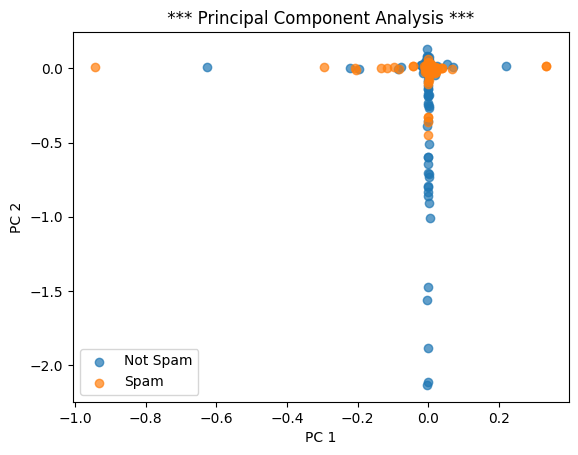

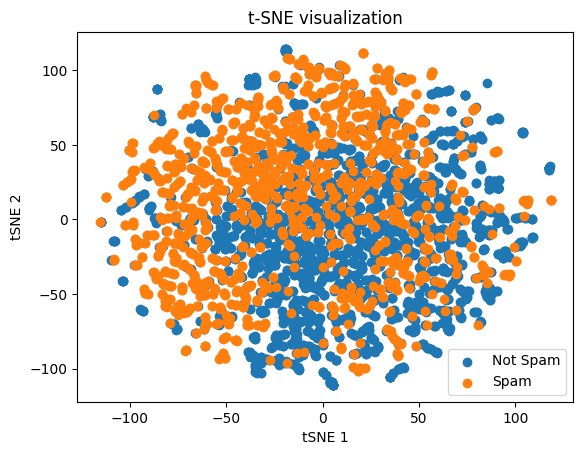

Done


In [23]:
# 1. we have to read, clean, organise the dataset
# 2. Experiment with ML models like Logistic regresion, decision tree, gradient boosting
# 3. Use PCA for data compression, dim redn = 10 dim
# 4. report classific results for each model on PCA.
# 5. Visualise using PCA and tSNE

# importing these using import statements
import numpy as np
import torch
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from ucimlrepo import fetch_ucirepo


# im fetch dataset reading the input file frm repo directly here
spambaseData = fetch_ucirepo(id=94)
# data (as pandas dataframes)
X = spambaseData.data.features
y = spambaseData.data.targets
learningrate = 0.1
n_estimators = 50
alpha = 0.7
labels = ['Not Spam', 'Spam']
# metadata
# print(spambaseData.metadata)

# variable information
# print(spambaseData.variables)

# printing sizes
X = np.array(X)
y = np.array(y).flatten()

print("\n")
print('Features i.e, X:', X.shape)
print('Labels i.e y:', y.shape)

# printing for impl of Logistic regression here
X_lr = X
y_lr = y      # actual y
model_LR = LogisticRegression(random_state = 42, max_iter= 1000).fit(X_lr, y_lr)
predict_LR = model_LR.predict(X_lr)                             # predicted y
accLR = np.mean(predict_LR == y) * 100
print("\n")
print("-"*100)
print("Without PCA")
print('Accuracy with logistic regression (no PCA):', accLR)


# using decision trees for implementation
X_dt = X
y_dt = y
model_DT = DecisionTreeClassifier(random_state = 42).fit(X_dt, y_dt)
predict_DT = model_DT.predict(X_dt)
accDT = np.mean(predict_DT == y_dt) * 100
print('Accuracy with decision tree (no PCA):', accDT)

# gradient boosting for imp
X_gb = X
y_gb = y
gradDesc = GradientBoostingClassifier(n_estimators = n_estimators, learning_rate = learningrate, random_state = 0).fit(X_gb, y_gb)
predict_GB = gradDesc.predict(X_gb)
acc_GB = np.mean(predict_GB == y_gb) * 100
print('Accuracy with gradient boosting (no PCA):', acc_GB)
print("-"*100)

# Principal Component Analysis

# 1. Compute mean
mu = np.mean(X, axis=0)
X_bar = X - mu
# 2. Compute covariance matrix
cov = np.cov(X_bar.transpose())
# 3. Eigen value decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov)
# Number of dimensions to keep
k = 10
# Projection matrix
P = eigenvectors[:, :k]
# Project data
X_pca = np.matmul(X_bar, P)


#  LOgistic REgression with PCA
model_pcaLogisticRegression = LogisticRegression(random_state = 42, max_iter=1000).fit(X_pca, y)
# Prediction
predict_pcaLR = model_pcaLogisticRegression.predict(X_pca)

# Accuracy with PCA compression / dimensionality reduction
LRacc_PCA = np.mean(predict_pcaLR == y) * 100
print("-"*100)
print("\n With PCA")
print('Accuracy of Logistic Regression (with PCA compression):', LRacc_PCA)


# Decision Tree with PCA
model_pcaDecisionTree = DecisionTreeClassifier(random_state = 42).fit(X_pca, y)
predict_pcaDT = model_pcaDecisionTree.predict(X_pca)

# Accuracy with PCA compression / dimensionality reduction
DTacc_PCA = np.mean(predict_pcaDT == y) * 100
print('Accuracy of Decision Tree (with PCA compression):', DTacc_PCA)

# Gradient Boosting with PCA
model_pcaGradientBoosting = GradientBoostingClassifier(n_estimators = n_estimators,
                                                       learning_rate = learningrate, random_state = 42).fit(X_pca, y)
predict_pcaGB = model_pcaGradientBoosting.predict(X_pca)

# Accuracy with PCA compression / dimensionality reduction
GBacc_PCA = np.mean(predict_pcaGB == y) * 100
print('Accuracy of Gradient boosting (with PCA compression):', GBacc_PCA)
print("-"*100)

## PCA Visualisation
for l in range(2):
	pca1 = X_pca[y == l, 0]
	pca2 = X_pca[y == l, 1]
	plt.scatter(pca1, pca2, label = labels[l], alpha = alpha)
plt.legend()
plt.title(' *** Principal Component Analysis *** ')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.savefig('PCA.png')
plt.show()
plt.clf()

# tSNE visualisation
X_tsne = TSNE(n_components = 2, learning_rate = 'auto', init = 'random', perplexity = 3).fit_transform(X_pca[:, :10])

for l in range(2):
	tsne1 = X_tsne[y == l, 0]
	tsne2 = X_tsne[y == l, 1]
	plt.scatter(tsne1, tsne2, label = labels[l])
plt.legend()
plt.title('t-SNE visualization')
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.savefig('tSNE.png')
plt.show()

print('Done')



Problem-4 : **CHATBOT**

In [26]:
# can run on terminal
# continuously ask LLM to make summary of the conversation
# add this summary it to the next prompt
# print conv and compare with gemini
import google.generativeai as genai
from google.colab import userdata
import os

# API KEY
# we are using api key here. loaded inside the var Api_KEY
API_KEY = userdata.get('API_KEY')
genai.configure(api_key=API_KEY)

previousConversation = []           # will store here prev conversations with ai
summary = "New Chat"                # some initial message summary
fullSummary = []                    # this will have the full summary frm start

# Load the model
model = genai.GenerativeModel("gemini-2.5-pro")

# some welcome msg to user
print("***Welcome User! Type 'exit' to quit or else type a question below***")
count = 0

while True:
    # Get user input continuously hence is specify in while loop until he says exit
    inputRequestFromUser = input("\nAsk me something: ").strip()

    # Check if your user has pressd exit. if exit no more response to be taken hence break
    if inputRequestFromUser == "exit":
        print("Goodbye! Have a great day.")
        break

    #  add summary to next prompt and add what user asked you also in that
    # user will not add summary while asking this is added directly. bcz he thinks the gpt knowd abotu your prev conversation
    prompt = f"Previous chat summary adding here: {summary}"
    prompt += f"\nUser: {inputRequestFromUser}\nPlease provide a helpful response:"

    # use generate_content model func gain some response from ai
    # based on prevConv and new reqyest we get new response fromai
    newResp = model.generate_content(prompt)
    # get only text bec it can be in other format jsoni think
    print(f"\nAIResp: {newResp.text}")

    # save this in list called previousConversation. no mess
    # both we need ere userinput and gpt response
    previousConversation.append(f"UserInput: {inputRequestFromUser}")
    previousConversation.append(f"AIResponseObtained: {newResp.text}")


    # it should have had atleast 4 conv compleeted till now
    # all the prev conv will useful in forming summary
    if len(previousConversation) >= 4:
        # then generate summary
        print("\n printing chat summary: ")

        # make this summary of the above conversation
        # make promt first
        previousConvString = " ".join(previousConversation[-4:])  # Last 2 exchanges
        summaryPrompt = f"This is the previos conversation: {previousConvString}."
        summaryPrompt += f"Please provide sumary of this conversation"
        summaryResponse = model.generate_content(summaryPrompt)         # model.generate_content will always get us Some resposne from AI for us.
        # get summary fetch text from summary that yu got
        summary = summaryResponse.text
        fullSummary.append(summary)

        print(f"Summarised: "+summary)

# Showing our previous chat displaying that
print("\n" + "-"*50)
print("Previous Messages :")
print("-"*50)
for convMsg in previousConversation:
    print(convMsg)

# summarising the whole conversation and displayng that summary generated
print("\n" + "-"*50)
print("Summarised Content:")
print("-"*50)
# fullSummary is a list it has all the summaries
for i, summary in enumerate(fullSummary, 1):
    print(f"Summary {i}: {summary}")



***Welcome User! Type 'exit' to quit or else type a question below***

Ask me something: How are you?

AIResp: Thanks for asking! As an AI, I don't have feelings or a personal state, but I'm functioning perfectly and am ready to help.

How can I assist you today?

Ask me something: I am wearing a yellow dress? what is the significance of a yellow dress?

AIResp: Of course! That's a wonderful and vibrant choice. A yellow dress is a powerful statement, and its significance is rich and multifaceted, drawing from psychology, culture, and fashion.

Here’s a breakdown of what a yellow dress can signify:

### 1. The Psychology and Emotion of Yellow

At its core, the significance of your yellow dress is tied to the color itself. Yellow is overwhelmingly associated with positive emotions.

*   **Happiness and Joy:** This is the most common association. Yellow is the color of sunshine, sunflowers, and smiley faces. Wearing it can project a sense of joy, optimism, and cheerfulness to others. It c

**Problem 5 : LLM_API to get EMBEDDINGS**

In [22]:
import google.generativeai as genai
from google.colab import userdata
import os

# API KEY
# we are using gemini api here
API_KEY = userdata.get('API_KEY')
genai.configure(api_key=API_KEY)

# Load the model
model = genai.GenerativeModel("gemini-2.5-pro")

# # Question Answering
# this is sending this request to ai and ai responses back
# responses = model.generate_content("Write a summary about Large Language Models (LLM).")

# the text tat we got will have multiple candidates/responses
# generate_content -> one resp obj
# for i, response in enumerate(responses):
# 	print(response.candidates[0].content.parts[0].text)

# Get embeddings for 4 sentences
sentences = [
    "I study Computer Science",
    "I learn Computer Engineering",
    "We learn Computer Science",
    "We study Computer Science and Computer Engineering"
]

# get the embedding for ech sentence frm sentences
for i, sentence in enumerate(sentences):
    result = genai.embed_content(
        model="text-embedding-004",
        content=sentence,
        task_type="retrieval_document",
        output_dimensionality=20  # Limit embedding size to 20
    )

    print(f"\nSentence : {sentence}")
    print(result['embedding'])


Sentence : I study Computer Science
[-0.002668373, -0.007002924, -0.09527657, -0.0036271424, 0.024797544, 0.019541493, 0.002165475, 0.028409896, -0.018734418, 0.016721116, 0.0062950053, 0.010313386, 0.06567957, -0.014763642, -0.004515892, -0.019287439, 0.025833864, 0.036357276, -0.09585416, 0.035041355]

Sentence : I learn Computer Engineering
[0.0013030831, -0.011818702, -0.07862751, 0.014445912, 0.029969627, 0.0011539815, 0.0054108994, 0.009536284, -0.017068464, 0.020247178, 0.0008837594, -0.0075590354, 0.064006664, -0.010558932, -0.0040601776, -0.038867332, 0.035677508, 0.03340209, -0.1041233, 0.024407284]

Sentence : We learn Computer Science
[-0.0018595563, 0.014690126, -0.062269825, -0.026924247, 0.018988924, 0.007066536, -0.012727012, 0.0010292843, -0.0029372117, 0.030724183, 0.009297237, -0.0032500823, 0.08967312, 0.013003159, -0.0017132163, -0.014582471, 0.04929346, 0.018904757, -0.11978554, 0.03394048]

Sentence : We study Computer Science and Computer Engineering
[-0.014612